In [1]:
import numpy as np
import pandas as pd
from candle_data import CandleData
from trade import Trade
from indicators import SMA
from optimiser import optimise
from plot_equity import plot_equity

# Data is loaded here

In [2]:
csv_file_name = "XAUUSD_M5_2020-01-01 00:00:00.csv"
data = CandleData(csv_file_name)

# Enter OnTick function here

In [3]:
def my_on_tick(
    data: CandleData,
    current_amount: float,
    timestamp: np.datetime64,
    trades: list[Trade],
    indicators: dict,
    params,
):
    fast_period = int(params[0])
    slow_period = int(params[1])
    sl_ratio = float(params[2])
    tp_ratio = float(params[3])

    candle_width = 300  # 5-minute bars
    min_required_time = timestamp - np.timedelta64(candle_width * slow_period, "s")
    if min_required_time < data.timestamps[0]:
        return 0.0

    # Manage active trades
    curr_open, curr_high, curr_low, curr_close = data.get_ohlc(timestamp, candle_width, time_is_open_time=True)

    # Entry logic: Simple Moving Average crossover
    fast_sma = indicators["fast_sma"]
    slow_sma = indicators["slow_sma"]

    fast_val = fast_sma(timestamp)
    slow_val = slow_sma(timestamp)

    # If no active trades, open a new position on bullish condition
    if fast_val > slow_val:
        buy_price = curr_close
        stop_loss = buy_price * (1.0 - sl_ratio)
        target = buy_price * (1.0 + tp_ratio)
        position_size = (current_amount * 0.02) / (buy_price - stop_loss)  # Risk 2%
        trades.append(Trade(timestamp, position_size, buy_price, stop_loss, target))

# Enter Objective function

In [4]:
def my_objective_function(starting_amount: float, trades: list[Trade]) -> float:
    """Differential evolution minimizes, so return negative total profit."""
    print("OF called")
    closed_trades = [t for t in trades if t.profit is not None]
    total_pnl = sum(t.profit for t in closed_trades)
    return -float(total_pnl)

# Setup required indicators here

In [5]:

# 3. Setup Indicators
indicators = {
    "fast_sma": SMA(data, candle_width=300, window_size=10),
    "slow_sma": SMA(data, candle_width=300, window_size=30),
}

# Run optimiser here

In [6]:
# 4. Run Walk-Forward Optimisation
# Params: [fast_period, slow_period, sl_ratio, tp_ratio]
bounds = [(5, 15), (20, 40), (0.005, 0.02), (0.01, 0.05)]
integrality = [True, True, False, False]

print("Running Walk-Forward Optimiser (Jan-Feb In-Sample, Mar Out-of-Sample)...")
res, out_sample_trades, in_sample_trades = optimise(
    start_month=1,
    start_year=2024,
    in_months=12,
    out_months=6,
    on_tick=my_on_tick,
    objective_function=my_objective_function,
    data=data,
    bounds=bounds,
    integrality=integrality,
    indicators=indicators,
)

print(f"Final parameter values -> {res.x}")

Running Walk-Forward Optimiser (Jan-Feb In-Sample, Mar Out-of-Sample)...
2024-01-01T00:00:00.000000000
OF called
OF called
OF called
OF called
OF called
OF called
OF called
OF called
OF called
OF called
OF called
OF called
OF called
OF called
OF called
OF called
OF called
OF called
OF called
OF called
OF called
OF called
OF called
OF called
OF called
OF called
OF called
OF called
OF called
OF called
OF called
OF called
OF called
OF called
OF called
OF called
OF called
OF called
OF called
OF called
OF called
OF called
OF called
OF called
OF called
OF called
OF called
OF called
OF called
OF called
OF called
OF called
OF called
OF called
OF called
OF called
OF called
OF called
OF called
OF called
OF called
OF called
OF called
OF called
OF called
OF called
OF called
OF called
OF called
OF called
OF called
OF called
OF called
OF called
OF called
OF called
OF called
OF called
OF called
OF called
OF called
OF called
OF called
OF called
OF called
OF called
OF called
OF called
OF called
OF call

# Plots quity Curve

Completed! Total Out-of-Sample trades executed: 628
Net Profit: 1694.88


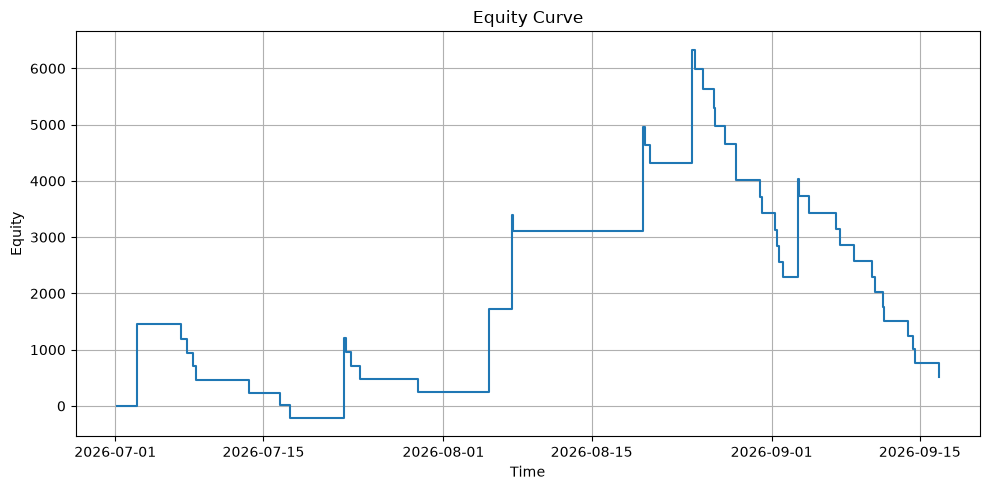

In [7]:

closed_trades = []
for trades in out_sample_trades:
    closed_trades += [t for t in trades if t.end_time is not None]
print(f"Completed! Total Out-of-Sample trades executed: {len(closed_trades)}")
if closed_trades:
    total_profit = sum(t.profit for t in closed_trades)
    print(f"Net Profit: {total_profit:.2f}")

    # 5. Plot equity
    plot_equity(trades)